In [ ]:
import os
import sys
import transformers
import torch
from xai_embeddings.models.BERT_model import BERT_model
from xai_embeddings.explainers.LOO_explainer import LOO_explainer
from xai_embeddings.explainers.subset_explainer import subset_explainer
from xai_embeddings.explainers.POS_permutation_explainer import POS_explainer
from xai_embeddings.explainers.attention_explainer import BertAttentionExplainer
from xai_embeddings.distances import euclidean_distance 


/home/ryba/Desktop/magisterka/xaiEmbeddings/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initialize Explainers


In [ ]:
mod = BERT_model("bert-base-uncased")
import xai_embeddings as xai
spacy_path = "en_core_web_trf"
pos_pfi = POS_explainer(
    mod,
    pos_dict="pos_dictionary.pkl",  # path to pos dictionary
    spacy=spacy_path,  # path to spacy model
    n=100,
    )

loo = LOO_explainer(mod)

# you can change distance to euclidean_distance, cosine is default
subset = subset_explainer(mod, distance=euclidean_distance, max_subsets=100)
att = BertAttentionExplainer(mod, aggregation_method="sum")


## Explanation Objects


### One token


In [3]:
exp1 = pos_pfi.explainOne("When I was little I caught bass fish", 6)
print(exp1)


Explanation(type=POS-PFI100)


### Multiple tokens


In [4]:
exp2 = pos_pfi.explainEmbeddings("When I was little I caught bass fish")
print(exp2)


Explanation(type=POS-PFI100)


Single word explanation share same object, but have only one token in explanation


In [5]:
print(len(exp1.scores), len(exp2.scores))


1 8


Scores are stored in dictionary with token position as a key


In [6]:
import json

print(json.dumps(exp1.scores, indent=2))


{
  "6": {
    "token": "bass",
    "intp": {
      "0": {
        "token": "when",
        "score": 0.03529078006744385
      },
      "1": {
        "token": "i",
        "score": 0.12937307894229888
      },
      "2": {
        "token": "was",
        "score": 0.027396368980407714
      },
      "3": {
        "token": "little",
        "score": 0.027526298761367796
      },
      "4": {
        "token": "i",
        "score": 0.12937307894229888
      },
      "5": {
        "token": "caught",
        "score": 0.07225037097930909
      },
      "7": {
        "token": "fish",
        "score": 0.6240920102596283
      }
    }
  }
}


Explanation Object also contain name of explainer, token list, original sentence


In [7]:
print("tokens", exp1.tokens)
print("sentence", exp1.sentence)
print("explainer", exp1.explanation_type)


tokens ['bass']
sentence bass
explainer POS-PFI100


### Plot single barchart


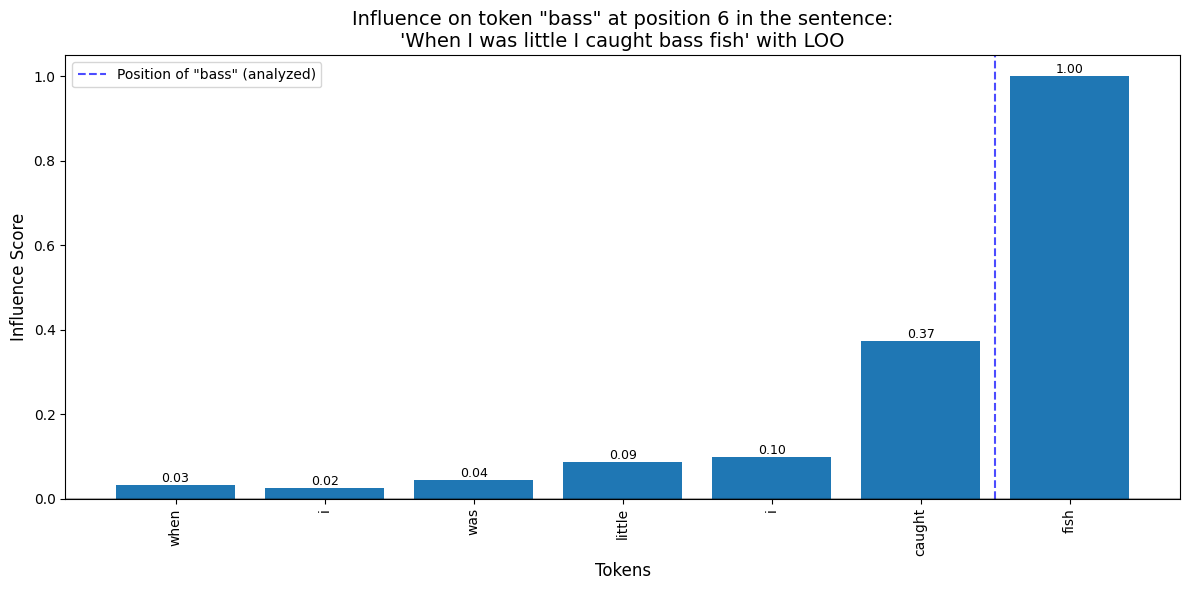

<module 'matplotlib.pyplot' from '/home/ryba/Desktop/magisterka/xaiEmbeddings/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

In [8]:
loo.explainOne("When I was little I caught bass fish", 6).plot_one(6, show=True)


### Circular Plot


[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Cleaning edge_properties and config parameters..
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Cleaning edge_properties and config parameters..
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Initializing [Chord]
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] filepath is set to [/tmp/d3blocks/temp_chord_diagram.html]
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Convert to DataFrame.
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Node properties are set.
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Set edge-opacity based on the [source] node-opacity.
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Set edge-colors based on the [source] node-color.
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] Edge properties are set.
[27-09-2025 23:37:32] [d3blocks.d3blocks] [INFO] File already exists and will be overwritten: [/tmp/d3blocks/temp_chord_diagram.html]


        target      source    weight
1          i:0        am:1  0.578972
2          i:0        an:2  0.554099
3          i:0   example:3  0.516593
4          i:0  sentence:4  0.417190
5          i:0         .:5  0.601003
6         am:1         i:0  0.248840
8         am:1        an:2  0.594860
9         am:1   example:3  0.526018
10        am:1  sentence:4  0.425521
11        am:1         .:5  0.609292
12        an:2         i:0  0.177796
13        an:2        am:1  0.177397
15        an:2   example:3  0.561817
16        an:2  sentence:4  0.479148
17        an:2         .:5  0.576718
18   example:3         i:0  0.171907
19   example:3        am:1  0.170218
20   example:3        an:2  0.257585
22   example:3  sentence:4  0.578293
23   example:3         .:5  0.692795
24  sentence:4         i:0  0.172823
25  sentence:4        am:1  0.145836
26  sentence:4        an:2  0.157944
27  sentence:4   example:3  0.294727
29  sentence:4         .:5  0.688647
30         .:5         i:0  0.148636
3

[27-09-2025 23:37:33] [d3blocks.d3blocks] [INFO] Open browser: /tmp/d3blocks/temp_chord_diagram.html


SVG saved to temp_chord_diagram.svg


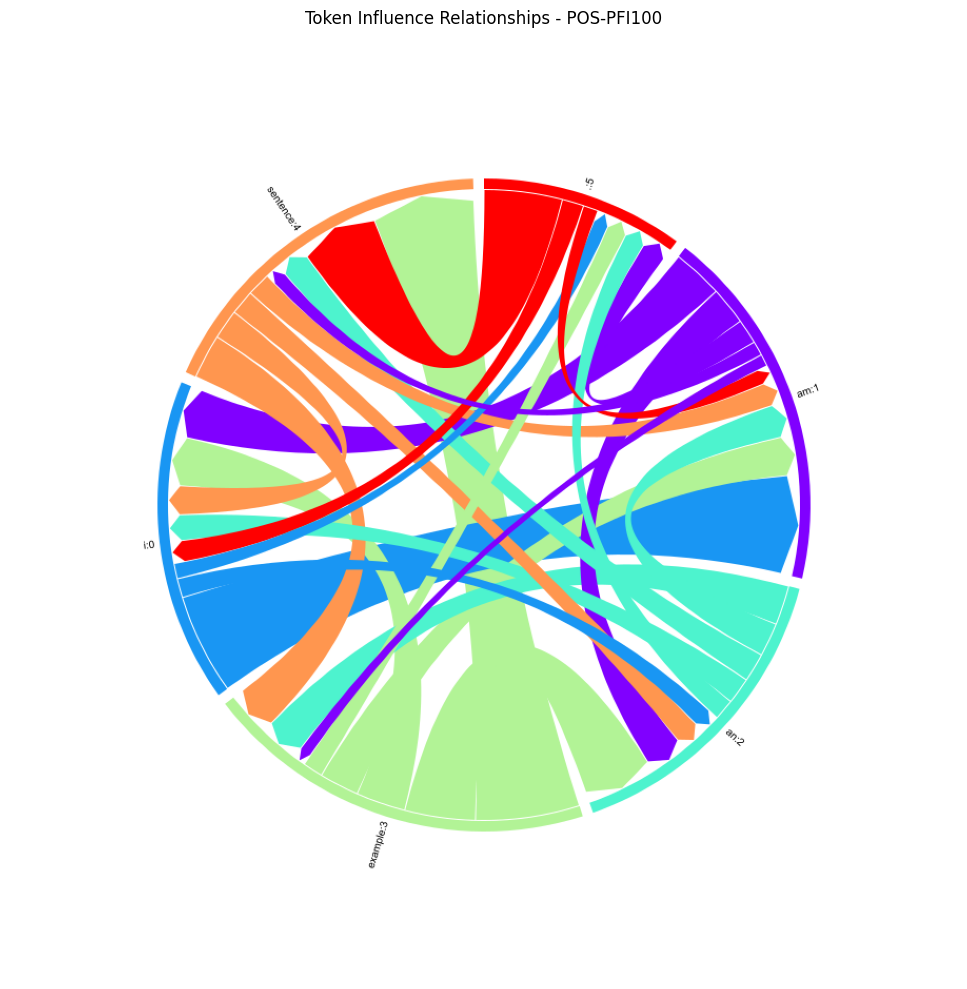

In [9]:
# Requires selenium and svglib for visualization in matplotlib with show=True 
pos_pfi.explainEmbeddings("I am an example sentence .").plot_self_comparison(show=True)


### Comparison Plot


Explaining token: "bass"


bass SHAP: 100%|██████████| 100/100 [00:24<00:00,  4.01subset/s]
BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Explaining token: "bass"


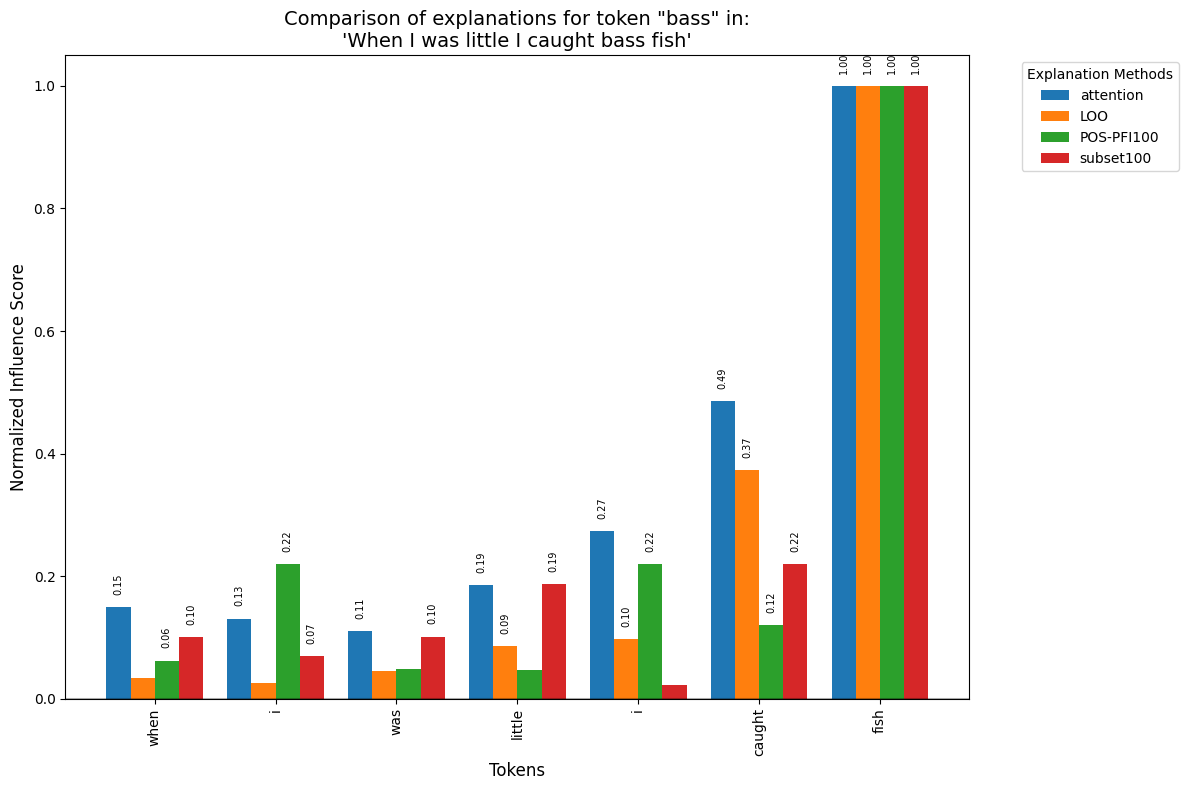

<module 'matplotlib.pyplot' from '/home/ryba/Desktop/magisterka/xaiEmbeddings/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

In [10]:
i = ("When I was little I caught bass fish", 6) # input sentence and index of target word

exps = []
exps.append(loo.explainOne(i[0], i[1]))
if "pos_pfi" in locals():
    exps.append(pos_pfi.explainOne(i[0], i[1]))
exps.append(subset.explainOne(i[0], i[1]))
att.explainOne(i[0], i[1]).plot_comparison(i[1], *exps, show=True)
